In [1]:
import sys
sys.path.append('..')
import numpy as np
from common.functions import softmax
from ch06.rnnlm import Rnnlm
from ch06.better_rnnlm import BetterRnnlm

class RnnlmGen(Rnnlm):
    def generate(self, start_id, skip_ids=None, sample_size=100):
        word_ids = [start_id]
        
        x = start_id
        while len(word_ids) < sample_size:
            x = np.array(x).reshape(1, 1)
            score = self.predict(x)
            p = softmax(score.flatten())
            
            sampled = np.random.choice(len(p), size=1, p=p)
            if (skip_ids is None) or (sampled not in skip_ids):
                x = sampled
                word_ids.append(int(x))
        
        return word_ids

In [3]:
import sys
sys.path.append('..')
from rnnlm_gen import RnnlmGen
from dataset import ptb

corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)
corpus_size = len(corpus)

model = RnnlmGen()
model.load_params('../ch06/Rnnlm.pkl')

# 시작 문자와 건너뜀 문자 설정
start_word = 'you'
start_id = word_to_id[start_word]
skip_words = ['N', '<unk>','$']
skip_ids = [word_to_id[w] for w in skip_words]

# 문장 생성
word_ids = model.generate(start_id, skip_ids)
txt = ' '.join([id_to_word[i] for i in word_ids])
txt = txt.replace(' <eos>', '.\n')
print(txt)

you could still encourage the project before it will be purchased for policies.
 overall less half of the time was announced oct. walker house group has n't yet been formed by sen. pont & co. group inc. on the reagan administration.
 when nicaragua controls includes its state employees and sent control corp. of waiver strength.
 the supreme court said chamber believed that officials is powerful pencils containing headquarters seeking to tackle plaintiffs fled after law and political administration volume but no threat to reform.
 that they participated in the second steps.
 carnival officials said the


In [1]:
import sys
sys.path.append('..')
from dataset import sequence

(x_train, t_train), (x_test, t_test) = sequence.load_data('addition.txt', seed=1984)
char_to_id, id_to_char = sequence.get_vocab()

In [2]:
class Encoder:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        v, d, h = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn
        
        embed_w = (rn(v, d) / 100).astype('f')
        lstm_wx = (rn(d, 4 * h) / np.sqrt(d)).astype('f')
        lstm_wh = (rn(h, 4 * h) / np.sqrt(h)).astype('f')
        lstm_b = np.zeros(4 * h).astype('f')
        
        self.embed = TimeEmbedding(embed_w)
        self.lstm = TimeLSTM(lstm_wx, lstm_wh, lstm_b, stateful=False)
        
        self.params = self.embed.params + self.lstm.params
        self.grads = self.embed.grads + self.lstm.grads
        self.hs = None
        
    def forward(self, xs):
        xs = self.embed.forward(xs)
        hs = self.lstm.forward(xs)
        self.hs = hs
        return hs[:, -1, :]
    
    def backward(self, dh):
        dhs = np.zeros_like(self.hs)
        dhs[:, -1, :] = dh
        
        dout = self.lstm.backward(dhs)
        dout = self.embed.backward(dout)
        return dout

In [5]:
class Decoder:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        v, d, h = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn
        
        embed_w = (rn(v, d) / 100).astype('f')
        lstm_wx = (rn(d, 4 * h) / np.sqrt(d)).astype('f')
        lstm_wh = (rn(h, 4 * h) / np.sqrt(h)).astype('f')
        lstm_b = np.zeros(4 * h).astype('f')
        affine_w = (rn(h, v) / np.sqrt(h)).astype('f')
        affine_b = np.zeros(v).astype('f')
        
        self.embed = TimeEmbedding(embed_w)
        self.lstm = TimeLSTM(lstm_wx, lstm_wh, lstm_b, stateful=True)
        self.affine = TimeAffine(affine_w, affine_b)
        self.params, self.grads = [], []
        for layer in (self.embed, self.lstm, self.affine):
            self.params += layer.params
            self.grads += layer.grads
            
    def forward(self, xs, h):
        self.lstm.set_state(h)
        
        out = self.lstm.forward(xs)
        out = self.lstm.forward(out)
        score = self.affine.forward(out)
        return score
    
    def backward(self, dscore):
        dout = self.affine.backward(dscore)
        dout = self.lstm.backward(dout)
        dout = self.embed.backward(dout)
        dh = self.lstm.dh
        return dh
    
    def generate(self, h, start_id, sample_size):
        sampled = []
        sample_id =start_id
        self.lstm.set_state(h)
        
        for _ in range(sample_size):
            x = np.array(sample_id).reshape((1, 1))
            out = self.embed.forward(x)
            out = self.lstm.forward(out)
            score = self.affine.forward(out)
            
            sample_id = np.argmax(score.flatten())
            sampled.append(int(sample_id))
            
        return sampled

In [6]:
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
from dataset import sequence
from common.optimizer import Adam
from common.trainer import Trainer
from common.util import eval_seq2seq
from seq2seq import Seq2seq
from peeky_seq2seq import PeekySeq2seq

# 데이터셋 읽기
(x_train, t_train), (x_test, t_test) = sequence.load_data('addition.txt')
char_to_id, id_to_char = sequence.get_vocab()

# 하이퍼파라미터 설정
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 128
batch_size = 128
max_epoch = 25
max_grad = 5.0

# 모델 / 옵티마이저 / 트레이너 생성
model = Seq2seq(vocab_size, wordvec_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1, batch_size=batch_size, max_grad=max_grad)
    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct, id_to_char, verbose)
    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print('검증 정확도 %.3f%%' % (acc * 100))

| 에폭 1 |  반복 1 / 351 | 시간 0[s] | 손실 2.56
| 에폭 1 |  반복 21 / 351 | 시간 0[s] | 손실 2.53
| 에폭 1 |  반복 41 / 351 | 시간 0[s] | 손실 2.17
| 에폭 1 |  반복 61 / 351 | 시간 1[s] | 손실 1.96
| 에폭 1 |  반복 81 / 351 | 시간 1[s] | 손실 1.92
| 에폭 1 |  반복 101 / 351 | 시간 2[s] | 손실 1.87
| 에폭 1 |  반복 121 / 351 | 시간 2[s] | 손실 1.85
| 에폭 1 |  반복 141 / 351 | 시간 3[s] | 손실 1.83
| 에폭 1 |  반복 161 / 351 | 시간 3[s] | 손실 1.79
| 에폭 1 |  반복 181 / 351 | 시간 3[s] | 손실 1.77
| 에폭 1 |  반복 201 / 351 | 시간 4[s] | 손실 1.77
| 에폭 1 |  반복 221 / 351 | 시간 4[s] | 손실 1.76
| 에폭 1 |  반복 241 / 351 | 시간 5[s] | 손실 1.76
| 에폭 1 |  반복 261 / 351 | 시간 5[s] | 손실 1.76
| 에폭 1 |  반복 281 / 351 | 시간 6[s] | 손실 1.75
| 에폭 1 |  반복 301 / 351 | 시간 6[s] | 손실 1.74
| 에폭 1 |  반복 321 / 351 | 시간 7[s] | 손실 1.75
| 에폭 1 |  반복 341 / 351 | 시간 7[s] | 손실 1.74
Q 77+85  
T 162 
X 100 
---
Q 975+164
T 1139
X 1000
---
Q 582+84 
T 666 
X 1000
---
Q 8+155  
T 163 
X 100 
---
Q 367+55 
T 422 
X 1000
---
Q 600+257
T 857 
X 1000
---
Q 761+292
T 1053
X 1000
---
Q 830+597
T 1427
X 1000
---
Q 26+838

Q 77+85  
T 162 
X 156 
---
Q 975+164
T 1139
X 1108
---
Q 582+84 
T 666 
X 658 
---
Q 8+155  
T 163 
X 173 
---
Q 367+55 
T 422 
X 411 
---
Q 600+257
T 857 
X 856 
---
Q 761+292
T 1053
X 1009
---
Q 830+597
T 1427
X 1410
---
Q 26+838 
T 864 
X 868 
---
Q 143+93 
T 236 
X 207 
---
검증 정확도 3.580%
| 에폭 9 |  반복 1 / 351 | 시간 0[s] | 손실 0.99
| 에폭 9 |  반복 21 / 351 | 시간 0[s] | 손실 1.02
| 에폭 9 |  반복 41 / 351 | 시간 1[s] | 손실 1.03
| 에폭 9 |  반복 61 / 351 | 시간 1[s] | 손실 1.05
| 에폭 9 |  반복 81 / 351 | 시간 2[s] | 손실 1.01
| 에폭 9 |  반복 101 / 351 | 시간 2[s] | 손실 0.99
| 에폭 9 |  반복 121 / 351 | 시간 3[s] | 손실 1.00
| 에폭 9 |  반복 141 / 351 | 시간 3[s] | 손실 1.00
| 에폭 9 |  반복 161 / 351 | 시간 4[s] | 손실 0.98
| 에폭 9 |  반복 181 / 351 | 시간 4[s] | 손실 0.99
| 에폭 9 |  반복 201 / 351 | 시간 5[s] | 손실 0.99
| 에폭 9 |  반복 221 / 351 | 시간 5[s] | 손실 0.98
| 에폭 9 |  반복 241 / 351 | 시간 6[s] | 손실 0.99
| 에폭 9 |  반복 261 / 351 | 시간 6[s] | 손실 0.99
| 에폭 9 |  반복 281 / 351 | 시간 7[s] | 손실 0.98
| 에폭 9 |  반복 301 / 351 | 시간 7[s] | 손실 0.97
| 에폭 9 |  반복 321 / 351 |

| 에폭 16 |  반복 181 / 351 | 시간 4[s] | 손실 0.87
| 에폭 16 |  반복 201 / 351 | 시간 5[s] | 손실 0.84
| 에폭 16 |  반복 221 / 351 | 시간 5[s] | 손실 0.87
| 에폭 16 |  반복 241 / 351 | 시간 6[s] | 손실 0.85
| 에폭 16 |  반복 261 / 351 | 시간 6[s] | 손실 0.88
| 에폭 16 |  반복 281 / 351 | 시간 7[s] | 손실 0.86
| 에폭 16 |  반복 301 / 351 | 시간 7[s] | 손실 0.84
| 에폭 16 |  반복 321 / 351 | 시간 8[s] | 손실 0.85
| 에폭 16 |  반복 341 / 351 | 시간 8[s] | 손실 0.86
Q 77+85  
T 162 
X 164 
---
Q 975+164
T 1139
X 1129
---
Q 582+84 
T 666 
X 677 
---
Q 8+155  
T 163 
X 159 
---
Q 367+55 
T 422 
X 427 
---
Q 600+257
T 857 
X 859 
---
Q 761+292
T 1053
X 1072
---
Q 830+597
T 1427
X 1418
---
Q 26+838 
T 864 
X 872 
---
Q 143+93 
T 236 
X 239 
---
검증 정확도 4.440%
| 에폭 17 |  반복 1 / 351 | 시간 0[s] | 손실 0.90
| 에폭 17 |  반복 21 / 351 | 시간 0[s] | 손실 0.85
| 에폭 17 |  반복 41 / 351 | 시간 1[s] | 손실 0.89
| 에폭 17 |  반복 61 / 351 | 시간 1[s] | 손실 0.90
| 에폭 17 |  반복 81 / 351 | 시간 2[s] | 손실 0.88
| 에폭 17 |  반복 101 / 351 | 시간 2[s] | 손실 0.87
| 에폭 17 |  반복 121 / 351 | 시간 3[s] | 손실 0.85
| 에폭 17 

검증 정확도 4.720%
| 에폭 24 |  반복 1 / 351 | 시간 0[s] | 손실 0.82
| 에폭 24 |  반복 21 / 351 | 시간 0[s] | 손실 0.79
| 에폭 24 |  반복 41 / 351 | 시간 0[s] | 손실 0.79
| 에폭 24 |  반복 61 / 351 | 시간 1[s] | 손실 0.79
| 에폭 24 |  반복 81 / 351 | 시간 1[s] | 손실 0.80
| 에폭 24 |  반복 101 / 351 | 시간 2[s] | 손실 0.79
| 에폭 24 |  반복 121 / 351 | 시간 2[s] | 손실 0.80
| 에폭 24 |  반복 141 / 351 | 시간 3[s] | 손실 0.79
| 에폭 24 |  반복 161 / 351 | 시간 3[s] | 손실 0.79
| 에폭 24 |  반복 181 / 351 | 시간 4[s] | 손실 0.80
| 에폭 24 |  반복 201 / 351 | 시간 4[s] | 손실 0.80
| 에폭 24 |  반복 221 / 351 | 시간 5[s] | 손실 0.81
| 에폭 24 |  반복 241 / 351 | 시간 5[s] | 손실 0.81
| 에폭 24 |  반복 261 / 351 | 시간 6[s] | 손실 0.78
| 에폭 24 |  반복 281 / 351 | 시간 6[s] | 손실 0.82
| 에폭 24 |  반복 301 / 351 | 시간 7[s] | 손실 0.80
| 에폭 24 |  반복 321 / 351 | 시간 7[s] | 손실 0.79
| 에폭 24 |  반복 341 / 351 | 시간 8[s] | 손실 0.78
Q 77+85  
T 162 
X 161 
---
Q 975+164
T 1139
X 1160
---
Q 582+84 
T 666 
X 667 
---
Q 8+155  
T 163 
X 160 
---
Q 367+55 
T 422 
X 417 
---
Q 600+257
T 857 
X 851 
---
Q 761+292
T 1053
X 1055
---
Q 83

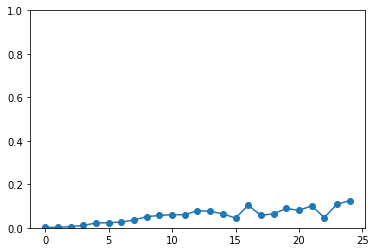

In [11]:
plt.plot(range(len(acc_list)), acc_list, 'o-')
plt.ylim([0,1])
plt.show()

In [12]:
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
from dataset import sequence
from common.optimizer import Adam
from common.trainer import Trainer
from common.util import eval_seq2seq
from seq2seq import Seq2seq
from peeky_seq2seq import PeekySeq2seq

# 데이터셋 읽기
(x_train, t_train), (x_test, t_test) = sequence.load_data('addition.txt')
char_to_id, id_to_char = sequence.get_vocab()
x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]

# 하이퍼파라미터 설정
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 128
batch_size = 128
max_epoch = 25
max_grad = 5.0

# 모델 / 옵티마이저 / 트레이너 생성
model = Seq2seq(vocab_size, wordvec_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

racc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1, batch_size=batch_size, max_grad=max_grad)
    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct, id_to_char, verbose)
    acc = float(correct_num) / len(x_test)
    racc_list.append(acc)
    print('검증 정확도 %.3f%%' % (acc * 100))

| 에폭 1 |  반복 1 / 351 | 시간 0[s] | 손실 2.56
| 에폭 1 |  반복 21 / 351 | 시간 0[s] | 손실 2.52
| 에폭 1 |  반복 41 / 351 | 시간 0[s] | 손실 2.17
| 에폭 1 |  반복 61 / 351 | 시간 1[s] | 손실 1.96
| 에폭 1 |  반복 81 / 351 | 시간 1[s] | 손실 1.91
| 에폭 1 |  반복 101 / 351 | 시간 2[s] | 손실 1.87
| 에폭 1 |  반복 121 / 351 | 시간 2[s] | 손실 1.86
| 에폭 1 |  반복 141 / 351 | 시간 2[s] | 손실 1.84
| 에폭 1 |  반복 161 / 351 | 시간 3[s] | 손실 1.80
| 에폭 1 |  반복 181 / 351 | 시간 3[s] | 손실 1.78
| 에폭 1 |  반복 201 / 351 | 시간 4[s] | 손실 1.77
| 에폭 1 |  반복 221 / 351 | 시간 4[s] | 손실 1.77
| 에폭 1 |  반복 241 / 351 | 시간 4[s] | 손실 1.76
| 에폭 1 |  반복 261 / 351 | 시간 5[s] | 손실 1.75
| 에폭 1 |  반복 281 / 351 | 시간 5[s] | 손실 1.74
| 에폭 1 |  반복 301 / 351 | 시간 6[s] | 손실 1.74
| 에폭 1 |  반복 321 / 351 | 시간 6[s] | 손실 1.74
| 에폭 1 |  반복 341 / 351 | 시간 7[s] | 손실 1.73
Q   58+77
T 162 
X 100 
---
Q 461+579
T 1139
X 1000
---
Q  48+285
T 666 
X 1001
---
Q   551+8
T 163 
X 100 
---
Q  55+763
T 422 
X 1001
---
Q 752+006
T 857 
X 1000
---
Q 292+167
T 1053
X 1000
---
Q 795+038
T 1427
X 1000
---
Q  838+6

Q   58+77
T 162 
X 163 
---
Q 461+579
T 1139
X 1134
---
Q  48+285
T 666 
O 666 
---
Q   551+8
T 163 
X 162 
---
Q  55+763
T 422 
X 423 
---
Q 752+006
T 857 
X 759 
---
Q 292+167
T 1053
O 1053
---
Q 795+038
T 1427
X 1431
---
Q  838+62
T 864 
X 866 
---
Q  39+341
T 236 
X 238 
---
검증 정확도 23.080%
| 에폭 9 |  반복 1 / 351 | 시간 0[s] | 손실 0.55
| 에폭 9 |  반복 21 / 351 | 시간 0[s] | 손실 0.56
| 에폭 9 |  반복 41 / 351 | 시간 1[s] | 손실 0.56
| 에폭 9 |  반복 61 / 351 | 시간 1[s] | 손실 0.55
| 에폭 9 |  반복 81 / 351 | 시간 2[s] | 손실 0.54
| 에폭 9 |  반복 101 / 351 | 시간 2[s] | 손실 0.55
| 에폭 9 |  반복 121 / 351 | 시간 2[s] | 손실 0.55
| 에폭 9 |  반복 141 / 351 | 시간 3[s] | 손실 0.54
| 에폭 9 |  반복 161 / 351 | 시간 3[s] | 손실 0.55
| 에폭 9 |  반복 181 / 351 | 시간 4[s] | 손실 0.53
| 에폭 9 |  반복 201 / 351 | 시간 4[s] | 손실 0.54
| 에폭 9 |  반복 221 / 351 | 시간 5[s] | 손실 0.54
| 에폭 9 |  반복 241 / 351 | 시간 5[s] | 손실 0.53
| 에폭 9 |  반복 261 / 351 | 시간 6[s] | 손실 0.53
| 에폭 9 |  반복 281 / 351 | 시간 6[s] | 손실 0.54
| 에폭 9 |  반복 301 / 351 | 시간 7[s] | 손실 0.54
| 에폭 9 |  반복 321 / 351 

| 에폭 16 |  반복 181 / 351 | 시간 4[s] | 손실 0.36
| 에폭 16 |  반복 201 / 351 | 시간 4[s] | 손실 0.38
| 에폭 16 |  반복 221 / 351 | 시간 5[s] | 손실 0.38
| 에폭 16 |  반복 241 / 351 | 시간 5[s] | 손실 0.36
| 에폭 16 |  반복 261 / 351 | 시간 6[s] | 손실 0.35
| 에폭 16 |  반복 281 / 351 | 시간 6[s] | 손실 0.35
| 에폭 16 |  반복 301 / 351 | 시간 7[s] | 손실 0.35
| 에폭 16 |  반복 321 / 351 | 시간 7[s] | 손실 0.35
| 에폭 16 |  반복 341 / 351 | 시간 8[s] | 손실 0.37
Q   58+77
T 162 
O 162 
---
Q 461+579
T 1139
X 1142
---
Q  48+285
T 666 
O 666 
---
Q   551+8
T 163 
O 163 
---
Q  55+763
T 422 
O 422 
---
Q 752+006
T 857 
X 858 
---
Q 292+167
T 1053
X 1054
---
Q 795+038
T 1427
X 1430
---
Q  838+62
T 864 
O 864 
---
Q  39+341
T 236 
X 237 
---
검증 정확도 42.700%
| 에폭 17 |  반복 1 / 351 | 시간 0[s] | 손실 0.34
| 에폭 17 |  반복 21 / 351 | 시간 0[s] | 손실 0.36
| 에폭 17 |  반복 41 / 351 | 시간 0[s] | 손실 0.36
| 에폭 17 |  반복 61 / 351 | 시간 1[s] | 손실 0.35
| 에폭 17 |  반복 81 / 351 | 시간 1[s] | 손실 0.36
| 에폭 17 |  반복 101 / 351 | 시간 2[s] | 손실 0.34
| 에폭 17 |  반복 121 / 351 | 시간 2[s] | 손실 0.34
| 에폭 17

검증 정확도 45.180%
| 에폭 24 |  반복 1 / 351 | 시간 0[s] | 손실 0.31
| 에폭 24 |  반복 21 / 351 | 시간 0[s] | 손실 0.29
| 에폭 24 |  반복 41 / 351 | 시간 1[s] | 손실 0.28
| 에폭 24 |  반복 61 / 351 | 시간 1[s] | 손실 0.29
| 에폭 24 |  반복 81 / 351 | 시간 2[s] | 손실 0.30
| 에폭 24 |  반복 101 / 351 | 시간 2[s] | 손실 0.29
| 에폭 24 |  반복 121 / 351 | 시간 2[s] | 손실 0.29
| 에폭 24 |  반복 141 / 351 | 시간 3[s] | 손실 0.29
| 에폭 24 |  반복 161 / 351 | 시간 3[s] | 손실 0.28
| 에폭 24 |  반복 181 / 351 | 시간 4[s] | 손실 0.29
| 에폭 24 |  반복 201 / 351 | 시간 4[s] | 손실 0.28
| 에폭 24 |  반복 221 / 351 | 시간 5[s] | 손실 0.28
| 에폭 24 |  반복 241 / 351 | 시간 5[s] | 손실 0.29
| 에폭 24 |  반복 261 / 351 | 시간 6[s] | 손실 0.29
| 에폭 24 |  반복 281 / 351 | 시간 6[s] | 손실 0.29
| 에폭 24 |  반복 301 / 351 | 시간 7[s] | 손실 0.28
| 에폭 24 |  반복 321 / 351 | 시간 7[s] | 손실 0.27
| 에폭 24 |  반복 341 / 351 | 시간 8[s] | 손실 0.29
Q   58+77
T 162 
O 162 
---
Q 461+579
T 1139
X 1140
---
Q  48+285
T 666 
O 666 
---
Q   551+8
T 163 
O 163 
---
Q  55+763
T 422 
X 421 
---
Q 752+006
T 857 
O 857 
---
Q 292+167
T 1053
X 1054
---
Q 7

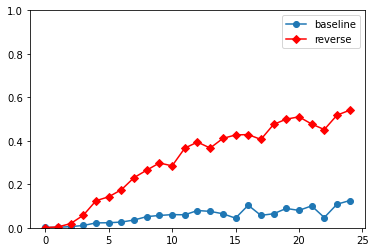

In [16]:
plt.plot(range(len(acc_list)), acc_list, 'o-', label='baseline')
plt.plot(range(len(racc_list)), racc_list, 'rD-', label='reverse')
plt.ylim([0,1])
plt.legend()
plt.show()

In [17]:
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
from dataset import sequence
from common.optimizer import Adam
from common.trainer import Trainer
from common.util import eval_seq2seq
from seq2seq import Seq2seq
from peeky_seq2seq import PeekySeq2seq

# 데이터셋 읽기
(x_train, t_train), (x_test, t_test) = sequence.load_data('addition.txt')
char_to_id, id_to_char = sequence.get_vocab()
x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]

# 하이퍼파라미터 설정
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 128
batch_size = 128
max_epoch = 25
max_grad = 5.0

# 모델 / 옵티마이저 / 트레이너 생성
model = PeekySeq2seq(vocab_size, wordvec_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

pracc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1, batch_size=batch_size, max_grad=max_grad)
    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct, id_to_char, verbose)
    acc = float(correct_num) / len(x_test)
    pracc_list.append(acc)
    print('검증 정확도 %.3f%%' % (acc * 100))

| 에폭 1 |  반복 1 / 351 | 시간 0[s] | 손실 2.57
| 에폭 1 |  반복 21 / 351 | 시간 0[s] | 손실 2.48
| 에폭 1 |  반복 41 / 351 | 시간 0[s] | 손실 2.20
| 에폭 1 |  반복 61 / 351 | 시간 1[s] | 손실 1.99
| 에폭 1 |  반복 81 / 351 | 시간 1[s] | 손실 1.89
| 에폭 1 |  반복 101 / 351 | 시간 2[s] | 손실 1.82
| 에폭 1 |  반복 121 / 351 | 시간 2[s] | 손실 1.82
| 에폭 1 |  반복 141 / 351 | 시간 3[s] | 손실 1.80
| 에폭 1 |  반복 161 / 351 | 시간 3[s] | 손실 1.79
| 에폭 1 |  반복 181 / 351 | 시간 3[s] | 손실 1.78
| 에폭 1 |  반복 201 / 351 | 시간 4[s] | 손실 1.77
| 에폭 1 |  반복 221 / 351 | 시간 4[s] | 손실 1.76
| 에폭 1 |  반복 241 / 351 | 시간 5[s] | 손실 1.76
| 에폭 1 |  반복 261 / 351 | 시간 5[s] | 손실 1.75
| 에폭 1 |  반복 281 / 351 | 시간 6[s] | 손실 1.74
| 에폭 1 |  반복 301 / 351 | 시간 6[s] | 손실 1.74
| 에폭 1 |  반복 321 / 351 | 시간 7[s] | 손실 1.73
| 에폭 1 |  반복 341 / 351 | 시간 7[s] | 손실 1.73
Q   58+77
T 162 
X 100 
---
Q 461+579
T 1139
X 1013
---
Q  48+285
T 666 
X 102 
---
Q   551+8
T 163 
X 100 
---
Q  55+763
T 422 
X 1023
---
Q 752+006
T 857 
X 1023
---
Q 292+167
T 1053
X 1023
---
Q 795+038
T 1427
X 1111
---
Q  838+6

Q   58+77
T 162 
X 161 
---
Q 461+579
T 1139
O 1139
---
Q  48+285
T 666 
X 657 
---
Q   551+8
T 163 
X 155 
---
Q  55+763
T 422 
O 422 
---
Q 752+006
T 857 
O 857 
---
Q 292+167
T 1053
O 1053
---
Q 795+038
T 1427
X 1438
---
Q  838+62
T 864 
O 864 
---
Q  39+341
T 236 
O 236 
---
검증 정확도 65.060%
| 에폭 9 |  반복 1 / 351 | 시간 0[s] | 손실 0.32
| 에폭 9 |  반복 21 / 351 | 시간 0[s] | 손실 0.31
| 에폭 9 |  반복 41 / 351 | 시간 1[s] | 손실 0.31
| 에폭 9 |  반복 61 / 351 | 시간 1[s] | 손실 0.31
| 에폭 9 |  반복 81 / 351 | 시간 2[s] | 손실 0.29
| 에폭 9 |  반복 101 / 351 | 시간 2[s] | 손실 0.29
| 에폭 9 |  반복 121 / 351 | 시간 3[s] | 손실 0.29
| 에폭 9 |  반복 141 / 351 | 시간 3[s] | 손실 0.27
| 에폭 9 |  반복 161 / 351 | 시간 4[s] | 손실 0.27
| 에폭 9 |  반복 181 / 351 | 시간 4[s] | 손실 0.26
| 에폭 9 |  반복 201 / 351 | 시간 5[s] | 손실 0.25
| 에폭 9 |  반복 221 / 351 | 시간 6[s] | 손실 0.25
| 에폭 9 |  반복 241 / 351 | 시간 6[s] | 손실 0.24
| 에폭 9 |  반복 261 / 351 | 시간 7[s] | 손실 0.24
| 에폭 9 |  반복 281 / 351 | 시간 7[s] | 손실 0.23
| 에폭 9 |  반복 301 / 351 | 시간 8[s] | 손실 0.22
| 에폭 9 |  반복 321 / 351 

| 에폭 16 |  반복 181 / 351 | 시간 4[s] | 손실 0.06
| 에폭 16 |  반복 201 / 351 | 시간 5[s] | 손실 0.05
| 에폭 16 |  반복 221 / 351 | 시간 5[s] | 손실 0.04
| 에폭 16 |  반복 241 / 351 | 시간 6[s] | 손실 0.04
| 에폭 16 |  반복 261 / 351 | 시간 7[s] | 손실 0.04
| 에폭 16 |  반복 281 / 351 | 시간 7[s] | 손실 0.03
| 에폭 16 |  반복 301 / 351 | 시간 8[s] | 손실 0.03
| 에폭 16 |  반복 321 / 351 | 시간 8[s] | 손실 0.03
| 에폭 16 |  반복 341 / 351 | 시간 9[s] | 손실 0.03
Q   58+77
T 162 
O 162 
---
Q 461+579
T 1139
O 1139
---
Q  48+285
T 666 
O 666 
---
Q   551+8
T 163 
O 163 
---
Q  55+763
T 422 
O 422 
---
Q 752+006
T 857 
O 857 
---
Q 292+167
T 1053
O 1053
---
Q 795+038
T 1427
O 1427
---
Q  838+62
T 864 
O 864 
---
Q  39+341
T 236 
O 236 
---
검증 정확도 97.000%
| 에폭 17 |  반복 1 / 351 | 시간 0[s] | 손실 0.04
| 에폭 17 |  반복 21 / 351 | 시간 0[s] | 손실 0.03
| 에폭 17 |  반복 41 / 351 | 시간 1[s] | 손실 0.02
| 에폭 17 |  반복 61 / 351 | 시간 1[s] | 손실 0.03
| 에폭 17 |  반복 81 / 351 | 시간 2[s] | 손실 0.03
| 에폭 17 |  반복 101 / 351 | 시간 2[s] | 손실 0.02
| 에폭 17 |  반복 121 / 351 | 시간 3[s] | 손실 0.02
| 에폭 17

검증 정확도 97.340%
| 에폭 24 |  반복 1 / 351 | 시간 0[s] | 손실 0.02
| 에폭 24 |  반복 21 / 351 | 시간 0[s] | 손실 0.02
| 에폭 24 |  반복 41 / 351 | 시간 1[s] | 손실 0.02
| 에폭 24 |  반복 61 / 351 | 시간 1[s] | 손실 0.01
| 에폭 24 |  반복 81 / 351 | 시간 2[s] | 손실 0.01
| 에폭 24 |  반복 101 / 351 | 시간 2[s] | 손실 0.01
| 에폭 24 |  반복 121 / 351 | 시간 3[s] | 손실 0.01
| 에폭 24 |  반복 141 / 351 | 시간 3[s] | 손실 0.01
| 에폭 24 |  반복 161 / 351 | 시간 4[s] | 손실 0.01
| 에폭 24 |  반복 181 / 351 | 시간 4[s] | 손실 0.01
| 에폭 24 |  반복 201 / 351 | 시간 5[s] | 손실 0.01
| 에폭 24 |  반복 221 / 351 | 시간 5[s] | 손실 0.01
| 에폭 24 |  반복 241 / 351 | 시간 6[s] | 손실 0.01
| 에폭 24 |  반복 261 / 351 | 시간 6[s] | 손실 0.01
| 에폭 24 |  반복 281 / 351 | 시간 7[s] | 손실 0.01
| 에폭 24 |  반복 301 / 351 | 시간 8[s] | 손실 0.01
| 에폭 24 |  반복 321 / 351 | 시간 8[s] | 손실 0.01
| 에폭 24 |  반복 341 / 351 | 시간 9[s] | 손실 0.01
Q   58+77
T 162 
O 162 
---
Q 461+579
T 1139
O 1139
---
Q  48+285
T 666 
O 666 
---
Q   551+8
T 163 
O 163 
---
Q  55+763
T 422 
O 422 
---
Q 752+006
T 857 
O 857 
---
Q 292+167
T 1053
O 1053
---
Q 7

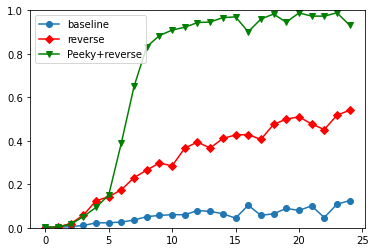

In [18]:
plt.plot(range(len(acc_list)), acc_list, 'o-', label='baseline')
plt.plot(range(len(racc_list)), racc_list, 'rD-', label='reverse')
plt.plot(range(len(pracc_list)), pracc_list, 'gv-', label='Peeky+reverse')
plt.ylim([0,1])
plt.legend(loc='upper left')
plt.show()